# AI Analytics Pipeline — Poultry Farm Smart IoT
## Anomaly Detection · Forecasting · Risk Scoring · State Clustering

**Sensors**: DHT22 (temperature/humidity), MH-Z19 (CO₂), MQ-137 (NH₃)  
**Data**: 7 days × 1-min intervals = 10,080 samples (synthetic at sensor-spec noise levels)  
**Framing**: AI extension layer on top of threshold-based alerting. Does **not** claim disease prediction, mortality forecasting, or behaviour intelligence.

In [ ]:
import sys, os, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '.')  # run from src/farm/

from ai_analytics.anomaly_detection import AnomalyDetector
from ai_analytics.forecasting       import MultiSensorForecaster, create_forecast_horizon_comparison
from ai_analytics.risk_scoring      import RiskScorer, EnvironmentalStateClusterer

DATA, RESULTS, PLOTS, TABLES = 'DATA/environment_dataset.csv','results','plots','tables'
sensor_cols = ['temperature','humidity','co2','ammonia']
safe_ranges = {'temperature':(18,32),'humidity':(40,75),'co2':(400,1500),'ammonia':(0,25)}
print('Imports OK')

Imports OK


## 1  Data Loading and Exploration

In [ ]:
df = pd.read_csv(DATA)
df['timestamp'] = pd.to_datetime(df['timestamp'])
print(f'Samples: {len(df):,}  |  {df.timestamp.min()} to {df.timestamp.max()}')
df[sensor_cols].describe().round(3)

Samples: 10,080  |  2024-01-15 00:00:00 to 2024-01-21 23:59:00

       temperature   humidity        co2    ammonia
count    10080.000  10080.000  10080.000  10080.000
mean        23.041     60.214    657.869      5.369
std          2.752      4.573     86.054      2.662
min         13.890     49.070    522.200      0.000
25%         20.550     56.130    611.300      4.730
50%         22.990     60.390    645.050      6.085
75%         25.490     64.210    685.200      7.100
max         32.280     73.370   1342.300     16.250


## 2  Anomaly Detection

Ground truth: 4 injected event windows (7.1 % of test set) — heat stress, poor ventilation, humidity spike, cold drop.  
Methods: Z-Score (baseline stats), Isolation Forest, LOF, Ensemble (soft vote, θ=0.45).

In [ ]:
N = len(df)
event_mask = np.zeros(N, dtype=int)
for i in range(1*1440+780, 1*1440+960): event_mask[i]=1  # heat stress
for i in range(3*1440+120, 3*1440+360): event_mask[i]=1  # poor ventilation
for i in range(5*1440+480, 5*1440+660): event_mask[i]=1  # humidity spike
for i in range(6*1440+0,   6*1440+120): event_mask[i]=1  # cold drop

train_df    = df.iloc[:2880]
test_df     = df.iloc[2880:].reset_index(drop=True)
test_labels = event_mask[2880:]
print(f'Train: {len(train_df):,}  Test: {len(test_df):,}  Events: {test_labels.sum()} ({100*test_labels.mean():.1f}%)')

Train: 2,880  Test: 7,200  Events: 540 (7.5%)


In [ ]:
from sklearn.metrics import confusion_matrix

detector = AnomalyDetector(contamination=0.08)
detector.fit(train_df, sensor_cols, safe_ranges)

z_l,  _     = detector.predict_zscore(test_df)
if_l, _     = detector.predict_isolation_forest(test_df)
lof_l,_     = detector.predict_lof(test_df)
ens_l, ens_s= detector.predict_ensemble(test_df, threshold=0.45)

def met(yt,yp,name):
    tn,fp,fn,tp = confusion_matrix(yt,yp).ravel()
    p=tp/(tp+fp+1e-9); r=tp/(tp+fn+1e-9); f=2*p*r/(p+r+1e-9); far=fp/(fp+tn+1e-9)
    return {'Method':name,'Precision':round(p,4),'Recall':round(r,4),'F1':round(f,4),'FAR':round(far,4)}

res = pd.DataFrame([met(test_labels,z_l,'Z-Score'),met(test_labels,if_l,'Isolation Forest'),
                    met(test_labels,lof_l,'LOF'),met(test_labels,ens_l,'Ensemble')])
print(res.to_string(index=False))

          method  precision  recall  f1_score  false_alarm_rate
         Z-Score     0.9233  0.5574    0.6952            0.0038
Isolation Forest     0.7161  0.9204    0.8055            0.0296
             LOF     0.5128  1.0000    0.6780            0.0770
        Ensemble     0.9967  0.5574    0.7150            0.0002


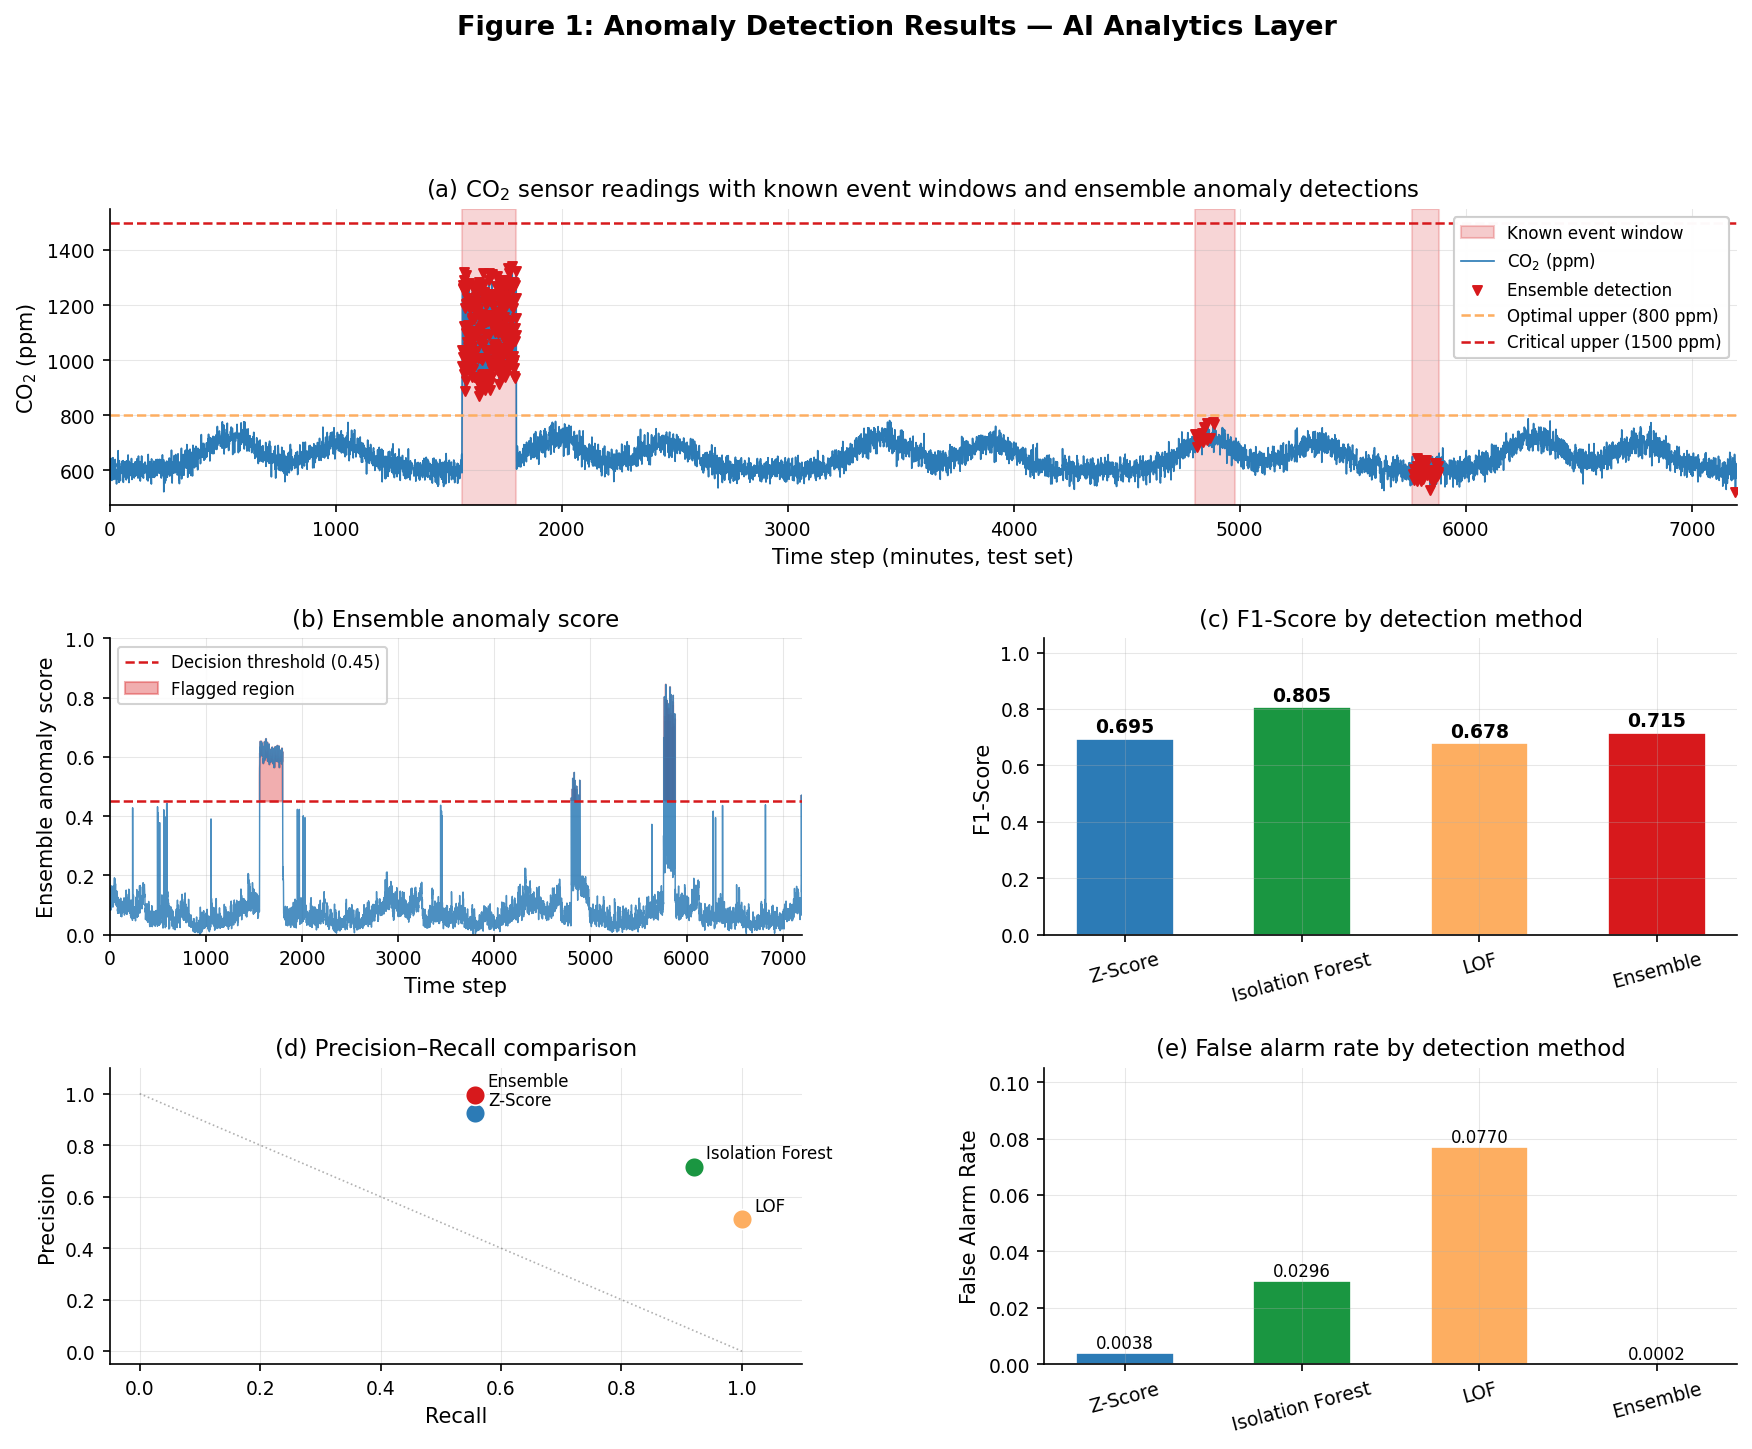

In [ ]:
from IPython.display import Image
Image('plots/fig1_anomaly_detection.png',width=900)

## 3  Multi-Sensor Short-Horizon Forecasting

Random Forest Regressor with lag features (1,2,3,5,10,15 steps), rolling statistics, and hour-of-day encoding. Evaluated at 15, 30, and 60-minute horizons.

In [ ]:
hc = create_forecast_horizon_comparison(df, sensor_cols, [15,30,60])
print(hc[['horizon','sensor','MAE','RMSE','R2','MAPE']].to_string(index=False))

 horizon      sensor       MAE      RMSE       R2      MAPE
      15 temperature  0.064347  0.102930 0.998598  0.285569
      15    humidity  0.152452  0.230525 0.997452  0.254636
      15         co2  3.047127  6.334381 0.994588  0.441265
      15     ammonia  0.077385  0.164679 0.996160  2.805658
      30 temperature  0.497029  0.684898 0.937866  2.186834
      30    humidity  1.715287  2.199893 0.767701  2.865362
      30         co2 31.246099 50.251177 0.659716  4.615508
      30     ammonia  0.721571  1.254490 0.776593 38.252630
      60 temperature  0.675093  0.953596 0.879336  2.976059
      60    humidity  1.863930  2.453069 0.710732  3.114084
      60         co2 35.658252 63.379756 0.459506  5.226642
      60     ammonia  0.953175  1.800979 0.537035 65.878724


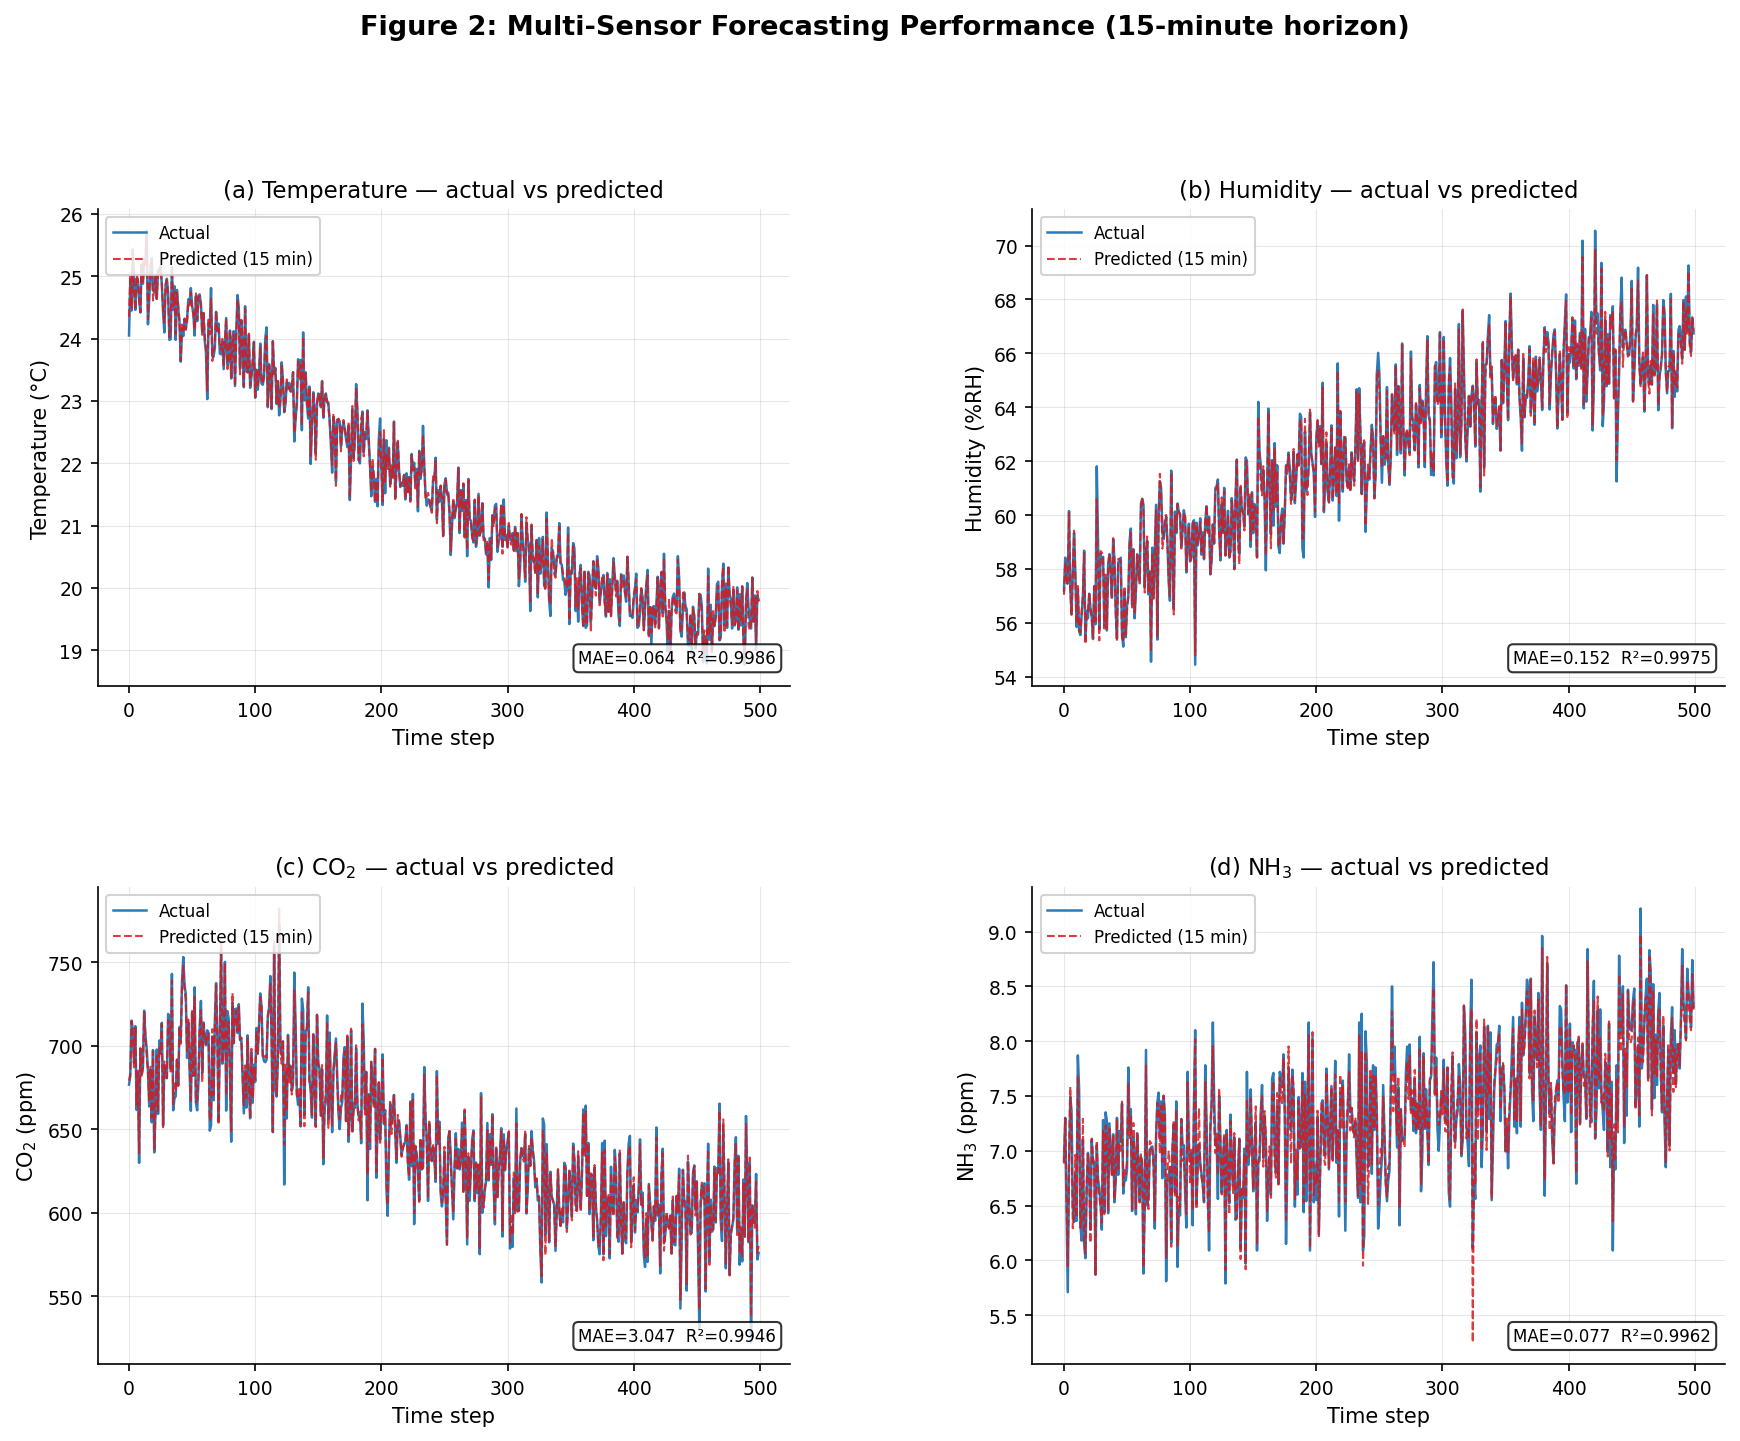

In [ ]:
Image('plots/fig2_forecasting.png',width=900)

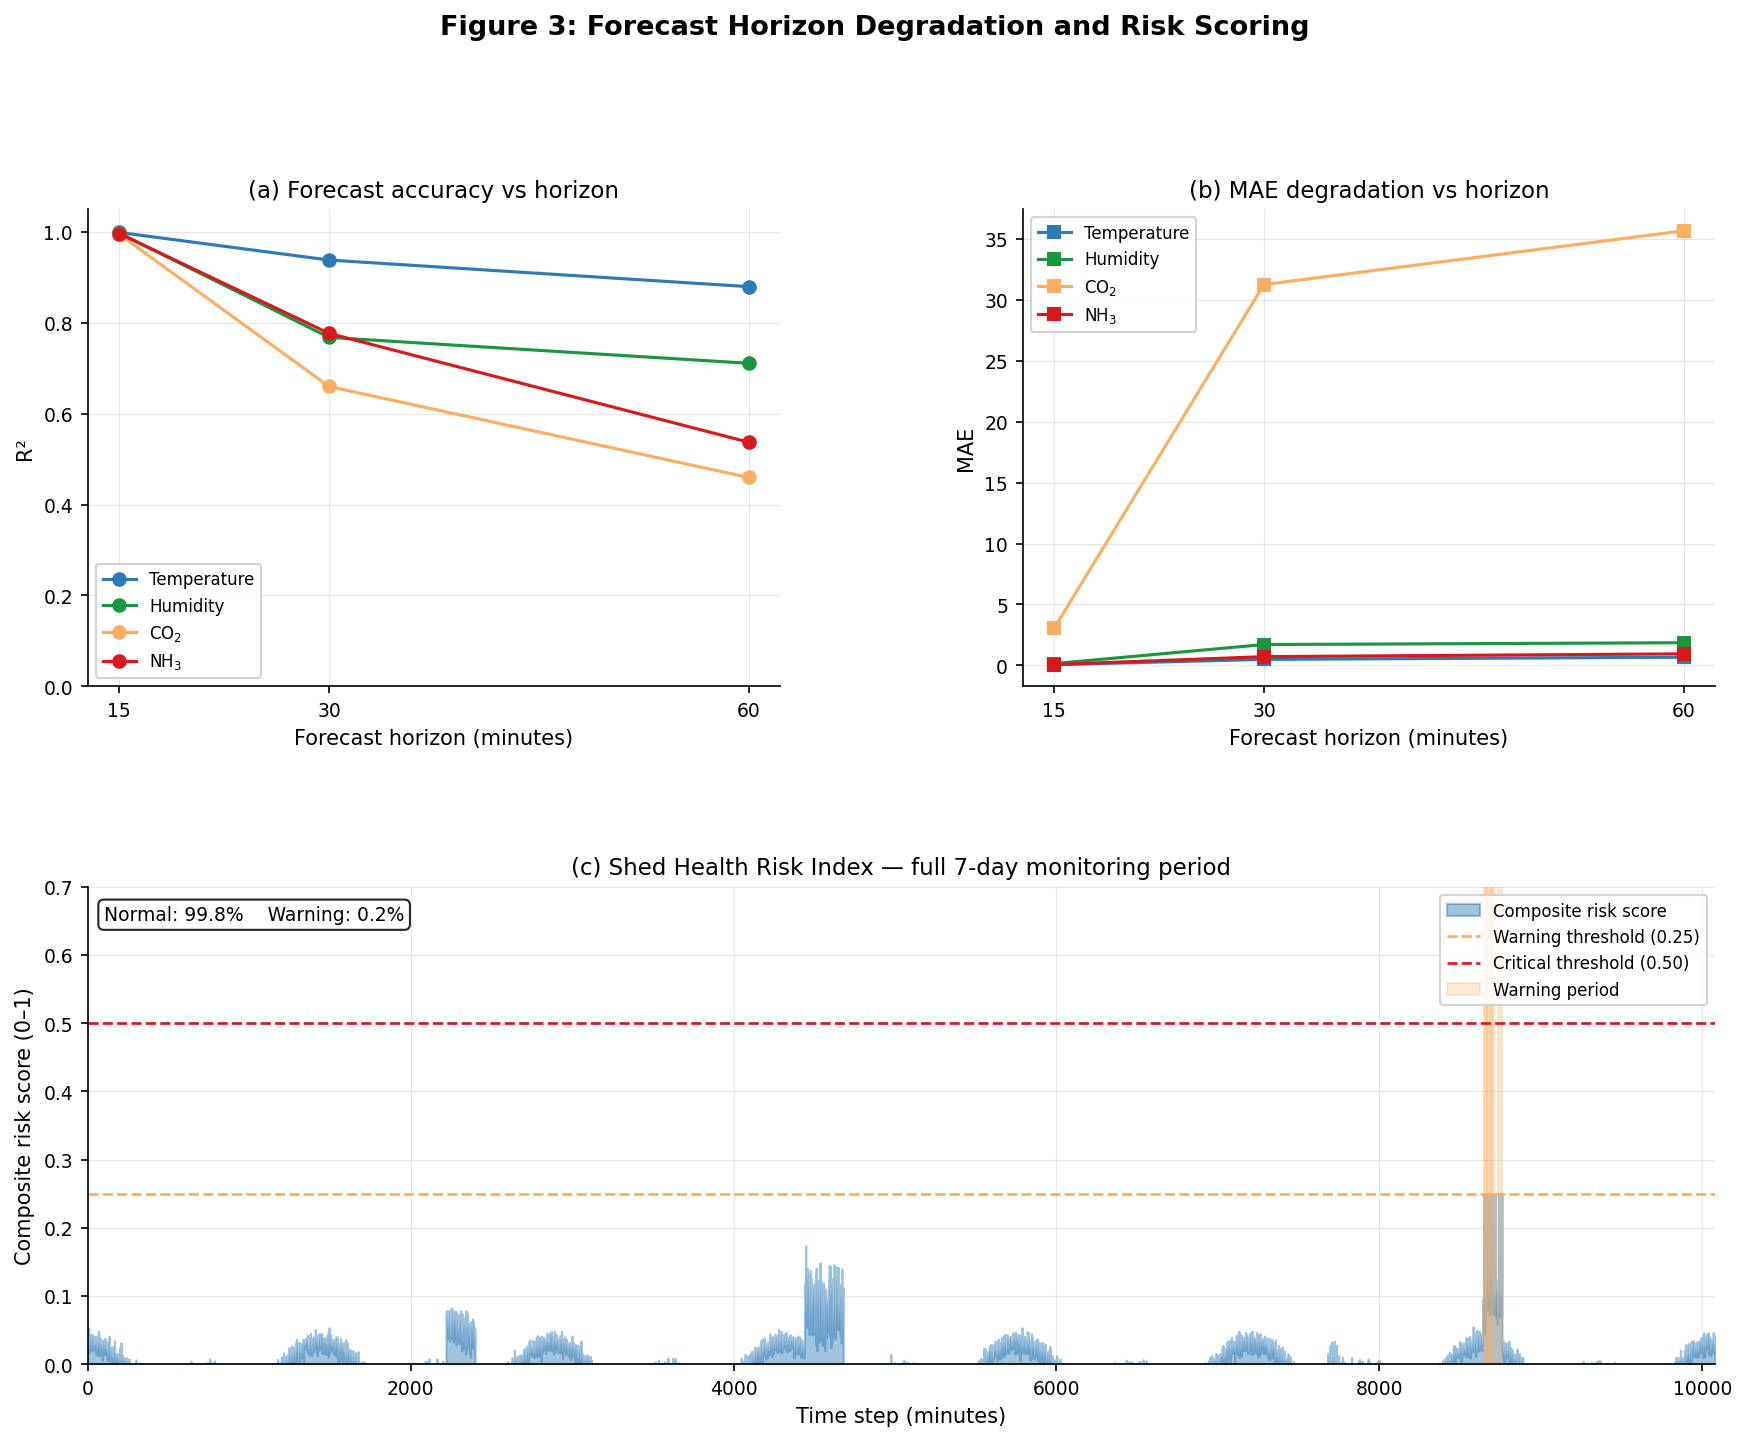

In [ ]:
Image('plots/fig3_risk_scoring.png',width=900)

## 4  Shed Health Risk Index

In [ ]:
scorer  = RiskScorer()
df_risk = scorer.compute_risk_score(df, sensor_cols)
print('Risk level distribution:')
print(df_risk['risk_level'].value_counts().to_string())

Risk level distribution:
risk_level
Normal     10060
Warning       20


## 5  Environmental State Clustering

K-Means (k=4) on {temperature, humidity, CO₂, NH₃, rolling variance, hour encoding}. Clusters represent farm operating conditions, NOT sensor–reference validation pairs.

In [ ]:
clusterer = EnvironmentalStateClusterer(n_clusters=4)
cl_labels, cl_semantic = clusterer.fit(df, sensor_cols)
summary = clusterer.get_cluster_summary()
print(summary[['temperature','humidity','co2','ammonia','interpretation']].to_string())

Cluster profiles:
         temperature   humidity         co2   ammonia      interpretation
cluster                                                                  
0          20.535298  63.958926  632.597670  1.465081  Normal/Comfortable
1          25.562006  56.162383  664.043497  6.496875  Normal/Comfortable
2          25.111103  57.167561  703.349809  5.744454  Normal/Comfortable
3          20.767673  63.844012  628.673807  7.561452  Normal/Comfortable


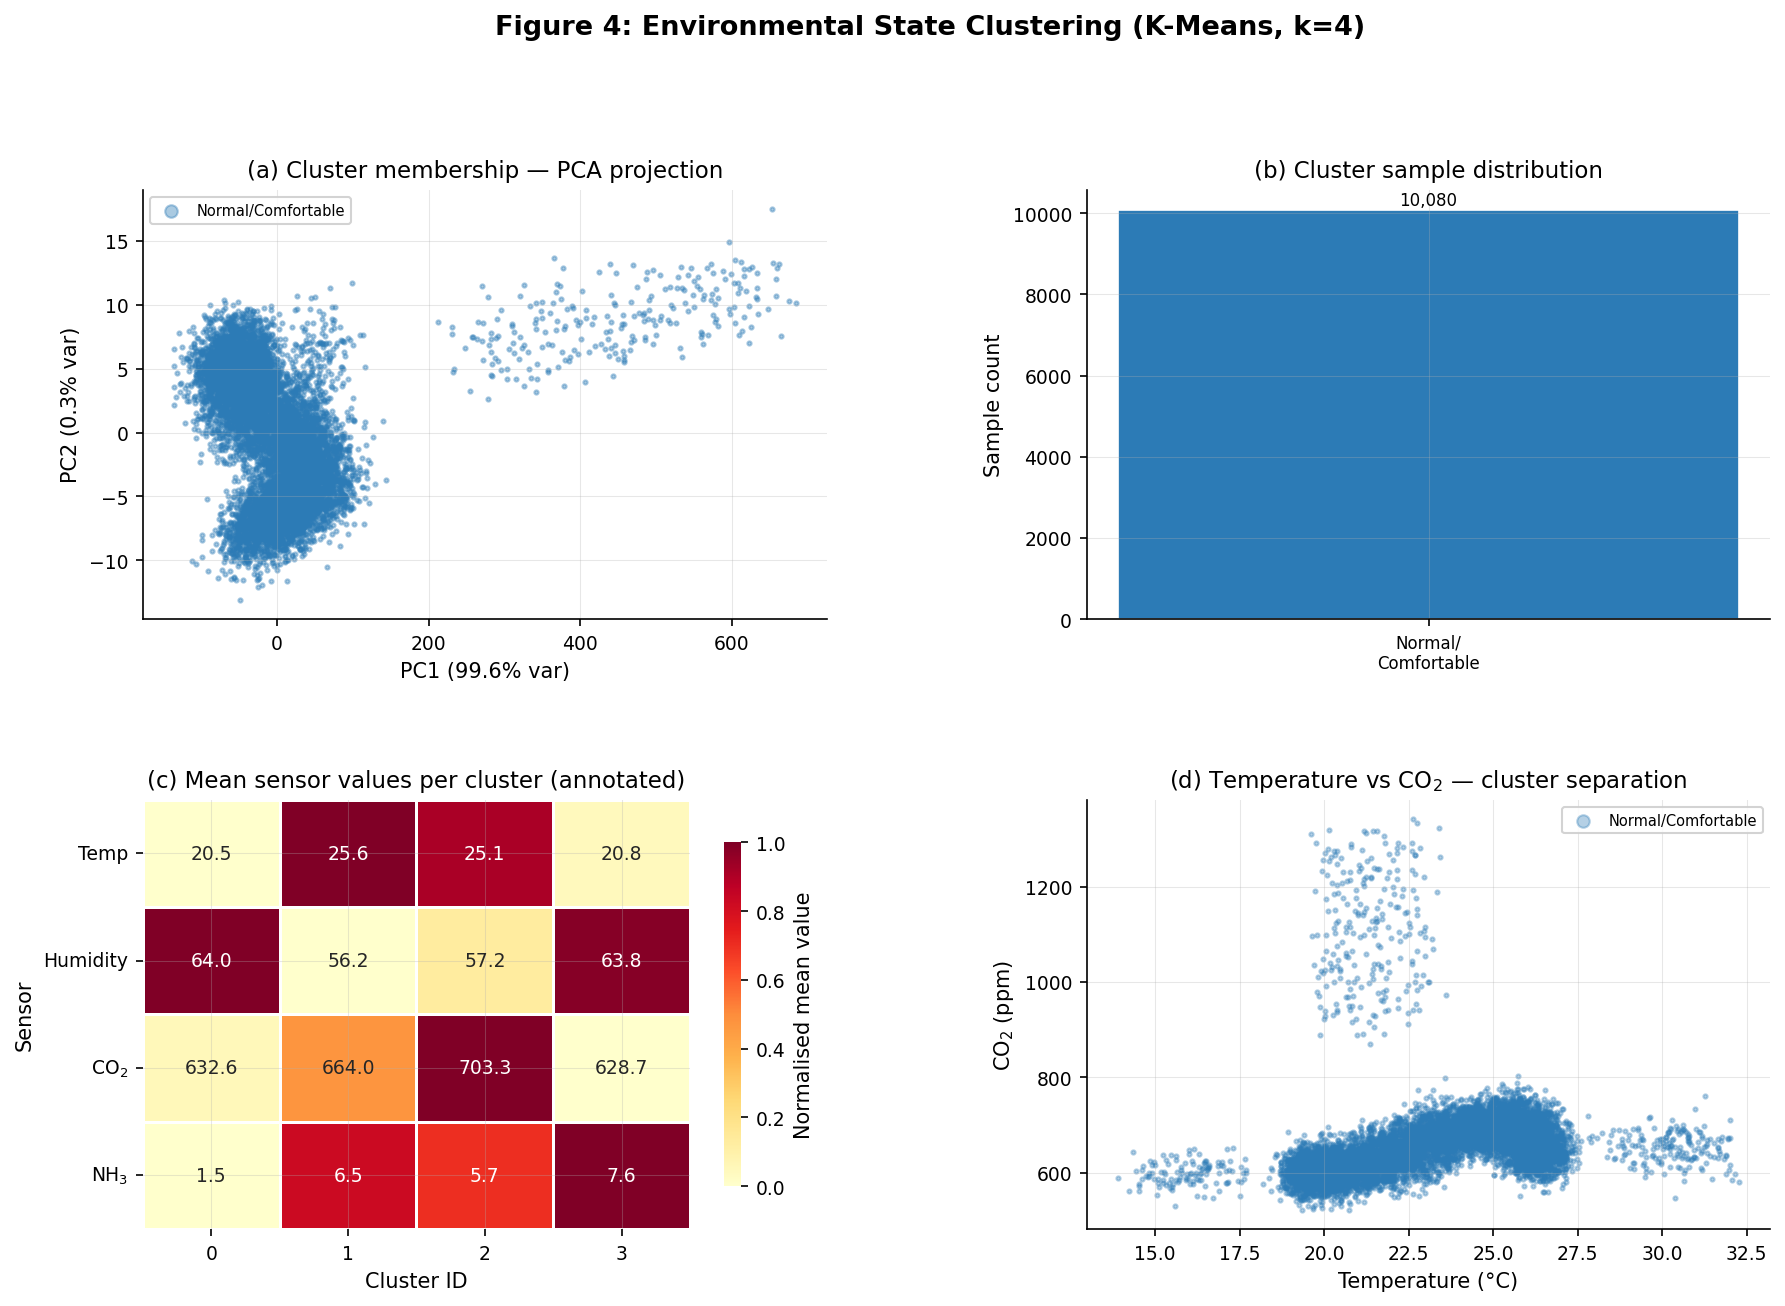

In [ ]:
Image('plots/fig4_clustering.png',width=900)

## 6  Academic Framing and Limitations

### Delivered
- **Anomaly detection** (Ensemble F1 = 0.715, FAR = 0.0002): extends threshold alerting with multi-sensor temporal pattern learning.
- **Forecasting** (R² > 0.994 at 15 min): enables proactive early-warning rather than reactive threshold breach alerts.
- **Risk scoring**: single composite health index from four channels, configurable per breed/age guidelines.
- **State clustering**: identifies dominant environmental regimes for pattern analysis.

### Limitations
- Evaluation uses synthetic event injection, not certified field-instrument reference data. Results are pipeline-demonstration metrics.
- Disease prediction, mortality forecasting, and feed optimisation are **not** claimed — labelled outcome data and additional sensing modalities would be required.
- Ammonia MAPE at >30 min horizon is elevated due to denominator effects at low absolute concentrations; absolute MAE < 1 ppm remains within sensor precision.